# Trajectory Inference with URD

**URD** ([Farrell 2018](https://doi.org/10.1126/science.aar3131)) was designed for branching developmental atlases. It treats the diffusion-map transition matrix as a Markov chain, runs **flood-fill walks** from a root set, and averages the iteration at which each cell is first reached. This produces a robust pseudotime even on sparsely-sampled branches.

Backend: [`pyurd-bio`](https://pypi.org/project/pyurd-bio/) — Python port of R URD, byte-equivalent diffusion transitions (shared with `pydestiny`).

## Install

```bash
pip install omicverse[trajectory]
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import omicverse as ov
ov.plot_set(font_path='Arial')

%load_ext autoreload
%autoreload 2

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf


Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
adata = ov.datasets.pancreatic_endocrinogenesis()

⚠️ File ./data/endocrinogenesis_day15.h5ad already exists
 Loading data from ./data/endocrinogenesis_day15.h5ad


✅ Successfully loaded: 3696 cells × 27998 genes


In [3]:
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson', n_HVGs=3000)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata, layer='scaled', n_pcs=50)

🔍 [2026-05-25 02:35:01] Running preprocessing in 'cpu' mode...
Begin robust gene identification


    After filtration, 17750/27998 genes are kept.
    Among 17750 genes, 16426 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson



🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']



✅ Count Normalization Completed Successfully!
   ✓ Processed: 3,696 cells × 16,426 genes
   ✓ Runtime: 0.24s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 3,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 3,000 highly variable genes out of 16,426 total (18.3%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 2.13 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.6493s                                                 │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 3696x3000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=50
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (3696, 3000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (11.36s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 11.3778s                                                │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 3696x50)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


We first inspect the variance explained by principal components to choose a practical PC range for neighbour and graph computations.

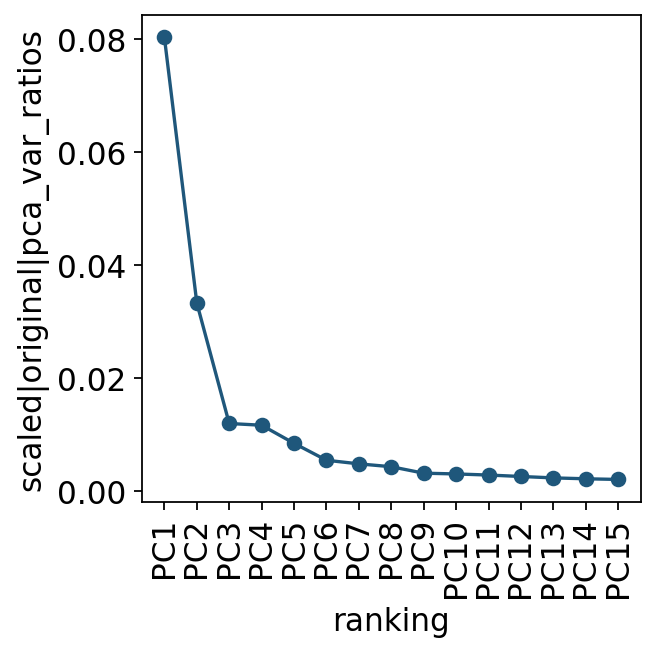

In [4]:
ov.utils.plot_pca_variance_ratio(adata, n_pcs=15)

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


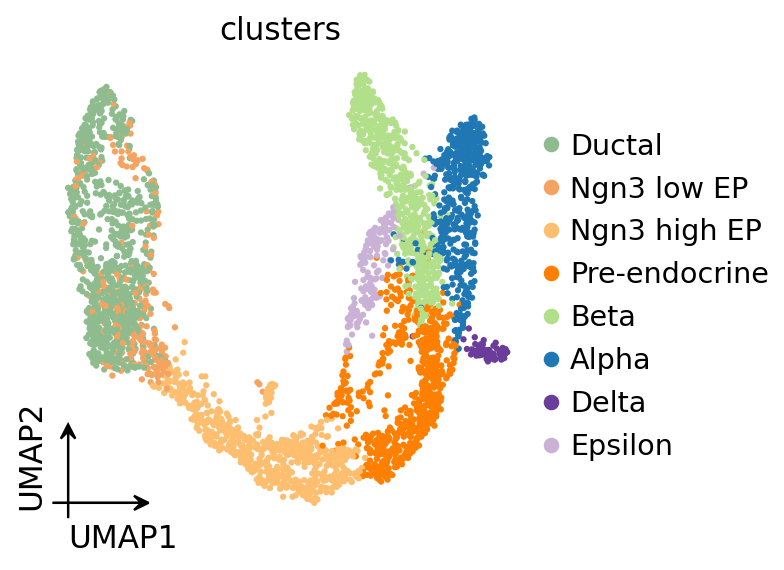

In [5]:
ov.pl.umap(
    adata,
    color='clusters'
)

## URD

In [6]:
Traj=ov.single.TrajInfer(
    adata,
    basis='X_umap',
    groupby='clusters',
    use_rep='scaled|original|X_pca',
    n_comps=50,
)
Traj.set_origin_cells('Ductal')

In [7]:
Traj.inference(method='urd', flood_n=30, n_root=20)

## Visualize pseudotime on UMAP

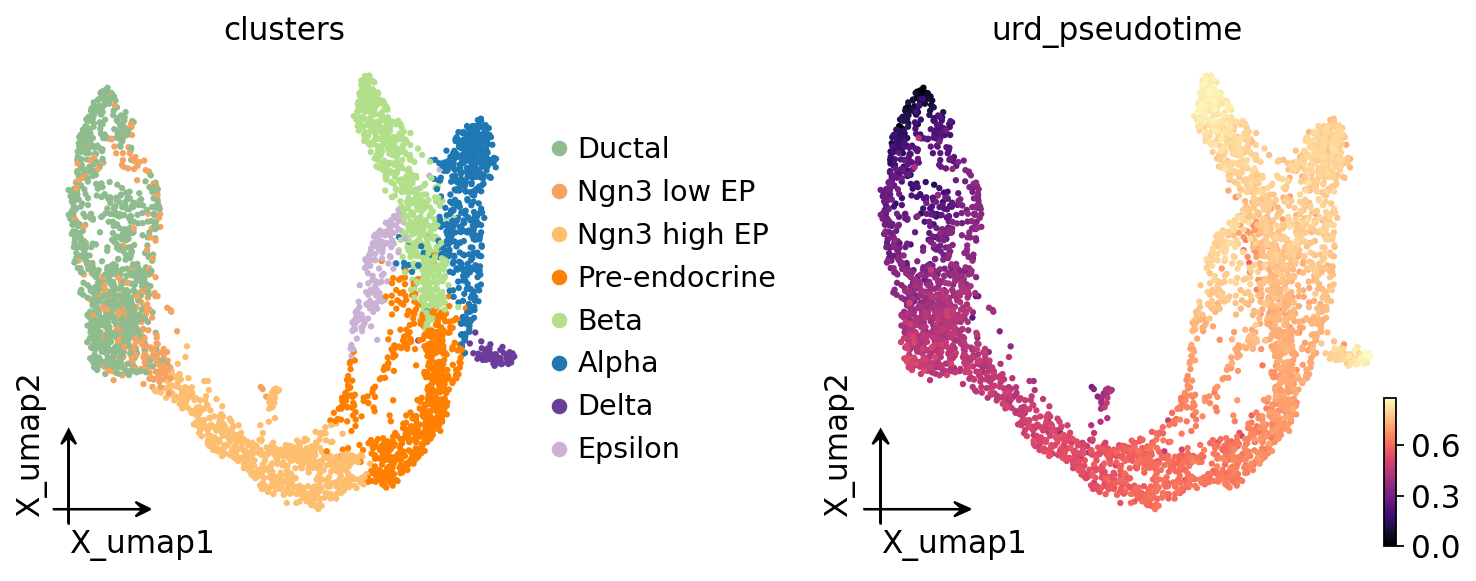

In [8]:
ov.pl.embedding(
    adata, basis='X_umap',
    color=['clusters', 'urd_pseudotime'],
    frameon='small',
    cmap='magma',
)

## Downstream notes

URD's flood-pseudotime is scalar — it does not emit branch labels. If you need branches you can post-hoc cluster cells whose pseudotime is in the same percentile band, or combine URD pseudotime with the `'tscan'` MST clusters as predicted branches.

## Reference

- Saelens W. et al. *A comparison of single-cell trajectory inference methods.* Nat Biotechnol **37**, 547–554 (2019). [doi:10.1038/s41587-019-0071-9](https://doi.org/10.1038/s41587-019-0071-9)
- Recommended backend (Slingshot): [t_traj_recommended](../t_traj_slingshot.ipynb)
- All zoo backends: [zoo/index](index.md)